**8.2**

Fitted parameters: Ie = 128781.86, re = 4.18, n = 2.00


/tmp/ipykernel_638659/789501083.py:38: RuntimeWarning: divide by zero encountered in power
  return Ie * np.exp(-bn * (r / re) ** n - 1)
/tmp/ipykernel_638659/789501083.py:38: RuntimeWarning: overflow encountered in exp
  return Ie * np.exp(-bn * (r / re) ** n - 1)
/tmp/ipykernel_638659/789501083.py:38: RuntimeWarning: overflow encountered in multiply
  return Ie * np.exp(-bn * (r / re) ** n - 1)


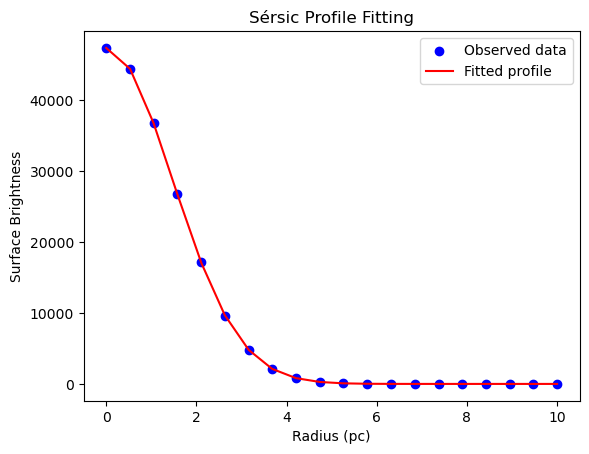

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = [
  0.00,  47373.98,
  0.53,  44447.19,
  1.05,  36728.40,
  1.58,  26730.46,
  2.11,  17122.92,
  2.63,  9643.88,
  3.16,  4806.90,
  3.68,  2109.92,
  4.21,  793.68,
  4.74,  289.23,
  5.26,  93.78,
  5.79,  32.29,
  6.32,  14.18,
  6.84,  3.27,
  7.37,  5.26,
  7.89,  2.89,
  8.42,  1.83,
  8.95,  0.82,
  9.47,  0.61,
  10.00, 0.93
]

radii, brightness = data[0::2], data[1::2]  #changed to take every second value, starting from either 0 or 1 


def sersic_profile(r, Ie, re, n):
    """
    Sérsic profile:
    I(r) = Ie * exp(-bn * ((r/re)^n - 1))
    bn can be approximated as 2n - 0.324
    """
    bn = 2 * n 
    return Ie * np.exp(-bn * (r / re) ** n - 1)

popt, pcov = curve_fit(sersic_profile, radii, brightness, p0=[5000, 10, 4]) #missed two entries

Ie_fit, re_fit, n_fit = popt  #did not unpack n_fit 

print(f"Fitted parameters: Ie = {Ie_fit:.2f}, re = {re_fit:.2f}, n = {n_fit:.2f}")  #change print into f-string

fig, ax = plt.subplots()
plt.scatter(radii, brightness, color='blue', label='Observed data')
ax.plot(radii, sersic_profile(radii, Ie_fit, re_fit, n_fit), color='red', label='Fitted profile') #missed a bracket
ax.set_xlabel("Radius (pc)")
ax.set_ylabel("Surface Brightness")
ax.set_title("Sérsic Profile Fitting")
ax.legend()
plt.show()

Play a puzzle game. Guess where to put the four pieces. Choose top left, top right, bottom left, or bottom right


Where to put the first piece? top left
Where to put the second piece? bottom left
Where to put the third piece? bottom right
Where to put the fourth piece? top right


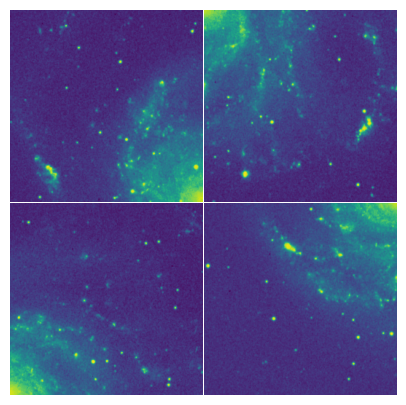

In [98]:
from astropy.io import fits
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np 

hdulist = fits.open('~/PROGNUM-repo/Task6/m101(1).fits')
dat = hdulist[0].data
datarr = np.asarray(dat, dtype='float64')

fig, axes = plt.subplots(2, 2, gridspec_kw={'wspace': 0, 'hspace': 0}, figsize=(5,5))

tl = (dat[265:530, 0:265])
tr = (dat[265:530, 265:530])
bl = (dat[0:265, 0:265])
br = (dat[0:265, 265:530])

axes[0, 0].axis('off')
axes[0, 1].axis('off')
axes[1, 0].axis('off')
axes[1, 1].axis('off')

print(f"Play a puzzle game. Guess where to put the four pieces. Choose top left, top right, bottom left, or bottom right")

part1 = input("Where to put the first piece?").strip().lower()
if part1 == 'top left':
    axes[0, 0].imshow(tl, origin='lower')
elif part1 == 'top right':
    axes[0, 1].imshow(tl, origin='lower')
elif part1 == 'bottom left':
    axes[1, 0].imshow(tl, origin='lower')
elif part1 == 'bottom right':
    axes[1, 1].imshow(tl, origin='lower')
else:
    print(f"Invalid position")
    sys.exit()

part2 = input("Where to put the second piece?").strip().lower()
if part2 == 'top left':
    axes[0, 0].imshow(tr, origin='lower')
elif part2 == 'top right':
    axes[0, 1].imshow(tr, origin='lower')
elif part2 == 'bottom left':
    axes[1, 0].imshow(tr, origin='lower')
elif part2 == 'bottom right':
    axes[1, 1].imshow(tr, origin='lower')
else: 
    print(f"Invalid position")
    sys.exit()

part3 = input("Where to put the third piece?").strip().lower()
if part3 == 'top left':
    axes[0, 0].imshow(bl, origin='lower')
elif part3 == 'top right':
    axes[0, 1].imshow(bl, origin='lower')
elif part3 == 'bottom left':
    axes[1, 0].imshow(bl, origin='lower')
elif part3 == 'bottom right':
    axes[1, 1].imshow(bl, origin='lower')
else: 
    print(f"Invalid position")
    sys.exit()

part4 = input("Where to put the fourth piece?").strip().lower()
if part4 == 'top left':
    axes[0, 0].imshow(br, origin='lower')
elif part4 == 'top right':
    axes[0, 1].imshow(br, origin='lower')
elif part4 == 'bottom left':
    axes[1, 0].imshow(br, origin='lower')
elif part4 == 'bottom right':
    axes[1, 1].imshow(br, origin='lower')
else: 
    print(f"Invalid position")
    sys.exit()
